# Name
Please write your name down here:

Peter Brederlow

**Exploratory analysis: Mouse strain phenotypes**

__Systems proteomics of liver mitochondria function__      
by Evan G. Williams, Yibo Wu, Pooja Jha, Sébastien Dubuis et al.     
_Science_     
Volume 352(6291):[aad0189](http://science.sciencemag.org/content/352/6291/aad0189)    
June 10, 2016, [doi:10.1126/science.aad0189](doi:10.1126/science.aad0189)

The __supplemental files__ are listed here: http://science.sciencemag.org/content/suppl/2016/06/10/352.6291.aad0189.DC1

We further include some methodology discussed in a related paper about mouse-human PheWAS (Phenome wide association studies)

__Joint mouse–human phenome-wide association to test gene function and disease risk__ <br>
by Xusheng Wang, Ashutosh K. Pandey, Megan K. Mulligan, Evan G. Williams et al.     
_Nature Communications_     
Volume 7, Article number: 10464, [doi:10.1038/ncomms10464](doi:10.1038/ncomms10464)     

In [147]:
# imports
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Phenotype overview

The phenotype data is in the supplemental file "aad0189_DataFileS2.xlsx" or "Data S2" or at `https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/phenotype.xlsx?raw=true`. Take a couple of minutes looking at it in a spreadsheet viewer.

The BXD mouse phenotype data has been accumulated over the past 50 years, with various measurements being available for different mice and different tissue types. The data provided by the paper supplement is structured as a multi-sheet Excel spreadsheet - you can open it in the corresponding software to get a first impression about the structure of the file.

## Load phenotype file into a pandas DataFrames `phenotypes`

The file contains multiple sheets. Pandas can load all of them into a single dictionary, whose keys correspond to sheet names, and values correspond to sheet contents as DataFrames.

Do the sheets have missing values? How are they encoded? Change your importing parameters accordingly.

In [148]:
#!pip install openpyxl

In [149]:
# YOUR CODE HERE
url = 'https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/phenotype.xlsx?raw=true'
phenotypes = pd.ExcelFile(url)

In [150]:
assert 'phenotypes' in locals()

## List all sheet names
And store them in `sheet_names`.

In [151]:
# YOUR CODE HERE
sheet_names = phenotypes.sheet_names
sheet_names

['Body Wt & Composition',
 'NIBP',
 'CLAMS',
 'OGTT',
 'ColdTest',
 'TSE',
 'VO2Max',
 'Activity Wheel',
 'Tissue_W',
 'Biochemistry',
 'Hematology',
 'NEW']

In [152]:
assert 'sheet_names' in locals()

In [153]:
phenotypes = pd.read_excel(url, sheet_name=None, na_values='x')
print("Sheet names:", phenotypes.keys())


Sheet names: dict_keys(['Body Wt & Composition', 'NIBP', 'CLAMS', 'OGTT', 'ColdTest', 'TSE', 'VO2Max', 'Activity Wheel', 'Tissue_W', 'Biochemistry', 'Hematology', 'NEW'])


/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-pa

## Peek into the a sheet of your choice

You can use the DataFrame method `.head()`.

In [154]:
# YOUR CODE HERE
activityWheel_data = phenotypes['Activity Wheel']
activityWheel_data.head()

,@format=column,CD_DayRun_ActivityWheel_[km],SE,N,HFD_DayRun_ActivityWheel_[km],SE.1,N.1,CD_NightRun_ActivityWheel_[km],SE.2,N.2,HFD_NightRun_ActivityWheel_[km],SE.3,N.3,CD_24hRun_ActivityWheel_[km],SE.4,N.4,HFD_24hRun_ActivityWheel_[km],SE.5,N.5
0,C57BL/6J,0.110775,0.044505,4,0.258075,0.057095,4.0,6.765900,0.771588,4,3.815375,0.691243,4.0,6.876650,0.759657,4,4.073425,0.647422,4.0
1,DBA/2J,0.000833,0.000833,3,0.807400,0.240083,5.0,3.390467,1.667547,3,7.370660,0.577015,5.0,3.651333,1.816531,3,8.477940,0.711399,5.0
2,BXD1,0.213000,0.127000,5,0.337000,0.129000,5.0,2.076000,0.836000,5,1.144000,0.170000,5.0,2.288600,0.823450,5,1.488000,0.274661,5.0
3,BXD2,0.064941,0.029647,4,0.110300,0.044630,5.0,0.408927,0.137838,4,2.050354,0.861755,5.0,0.473750,0.157773,4,2.158800,0.868721,5.0
4,BXD6,0.117778,0.102737,5,0.266555,0.051491,5.0,3.084563,1.170924,5,0.863286,0.122457,5.0,3.200800,1.178263,5,1.127000,0.164309,5.0


## List all columns of the Biochemistry sheet

**What do all those columns `SE` and `N` mean?**

In [155]:
# YOUR CODE HERE
activityWheel_data = phenotypes['Biochemistry']
for col in biochemistry_data.columns:
    print(col)

@format=column
CD_Glucose_[mmol/L]
SE
N
HFD_Glucose_[mmol/L]
SE.1
N.1
CD_Cholesterol_[mmol/L]
SE.2
N.2
HFD_Cholesterol_[mmol/L]
SE.3
N.3
CD_HDL_[mmol/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.4
N.4
HFD_HDL_[mmol/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.5
N.5
CD_HDL_Norm[Z]
SE.6
N.6
HFD_HDL_Norm[Z]
SE.7
N.7
CD_LDL_[mmol/L]
SE.8
N.8
HFD_LDL_[mmol/L]
SE.9
N.9
CD_Triglycerides_[mmol/L]
SE.10
N.10
HFD_Triglycerides_[mmol/L]
SE.11
N.11
CD_FFA_[mmol/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.12
N.12
HFD_FFA_[mmol/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.13
N.13
CD_FFA_Norm[Z]
SE.14
N.14
HFD_FFA_Norm[Z]
SE.15
N.15
CD_LacticAcid_[mmol/L]
SE.16
N.16
HFD_LacticAcid_[mmol/L]
SE.17
N.17
CD_BloodProtein_[g/L]
SE.18
N.18
HFD_BloodProtein_[g/L]
SE.19
N.19
CD_ALAT_[U/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.20
N.20
HFD_ALAT_[U/L]_KNOWN_BATCH_EFFECT_BY_COHORT_ORDER
SE.21
N.21
CD_ASAT_[U/L]
SE.22
N.22
HFD_ASAT_[U/L]
SE.23
N.23
CD_ASAT_Norm[Z]
SE.24
N.24
HFD_ASAT_Norm[Z]
SE.25
N.25
CD_LDH_[U/L]_KNOWN_BATCH_E

N describes the sample size, SE is the standard error of the measurement.

## Look at the variability across different strains for some phenotypes

Examples:
- basal body temperature
- alkaline phosphatase (ALPL) protein activity level
- weight after 28 weeks

Create a histogram out of 2-3 phenotype measurements of your choice.

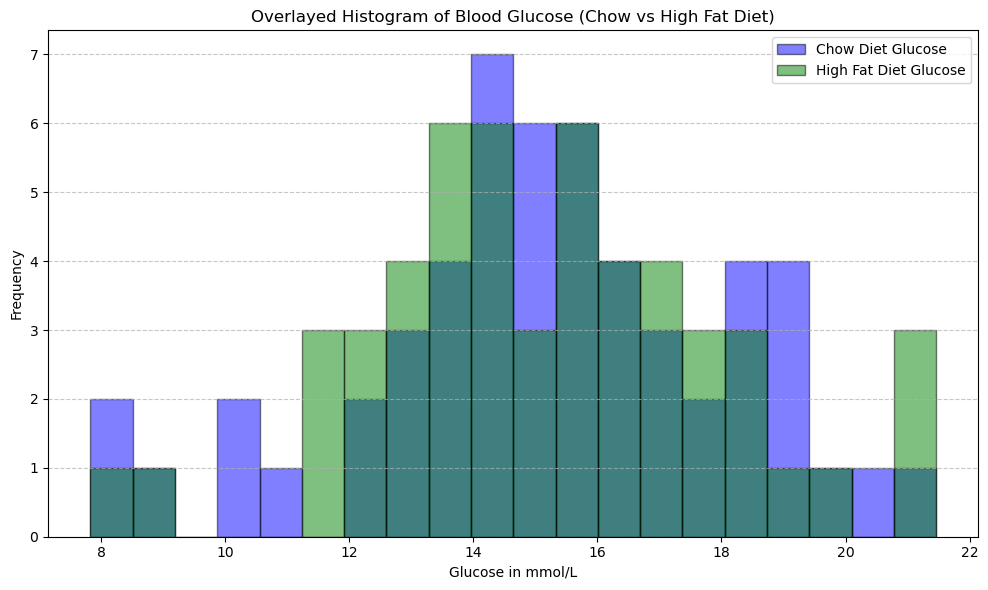

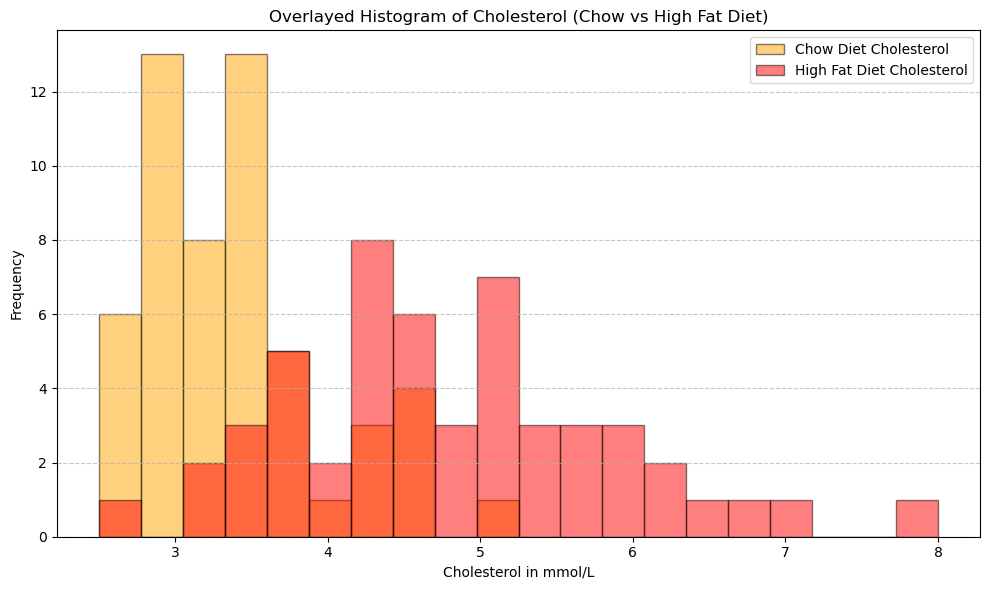

In [156]:
# YOUR CODE HERE
biochemistry_data = biochemistry_data.replace('x', np.nan)
CD_Glucose = biochemistry_data.iloc[:, 1].astype(float).dropna()  
HFD_Glucose = biochemistry_data.iloc[:, 4].astype(float).dropna()
CD_Cholesterol = biochemistry_data.iloc[:, 7].astype(float).dropna()  
HFD_Cholesterol = biochemistry_data.iloc[:, 10].astype(float).dropna() 

#glucose
min_value = min(CD_Glucose.min(), HFD_Glucose.min())
max_value = max(CD_Glucose.max(), HFD_Glucose.max())
bins = np.linspace(min_value, max_value, 21)
plt.figure(figsize=(10, 6))
plt.hist(CD_Glucose, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='Chow Diet Glucose')
plt.hist(HFD_Glucose, bins=bins, color='green', alpha=0.5, edgecolor='black', label='High Fat Diet Glucose')
plt.xlabel('Glucose in mmol/L')
plt.ylabel('Frequency')
plt.title('Overlayed Histogram of Blood Glucose (Chow vs High Fat Diet)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#cholesterol
min_value = min(CD_Cholesterol.min(), HFD_Cholesterol.min())
max_value = max(CD_Cholesterol.max(), HFD_Cholesterol.max())
bins = np.linspace(min_value, max_value, 21) 
plt.figure(figsize=(10, 6))
plt.hist(CD_Cholesterol, bins=bins, color='orange', alpha=0.5, edgecolor='black', label='Chow Diet Cholesterol')
plt.hist(HFD_Cholesterol, bins=bins, color='red', alpha=0.5, edgecolor='black', label='High Fat Diet Cholesterol')
plt.xlabel('Cholesterol in mmol/L')
plt.ylabel('Frequency')
plt.title('Overlayed Histogram of Cholesterol (Chow vs High Fat Diet)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()





## Compare 'Activity Wheel' values across strains, diets and times

The diets are CD (Chow Diet) and HFD (High Fat Diet).

Use a seaborn `pairplot` to display all pairwise comparisons at once. Add regressions to the pairplot.

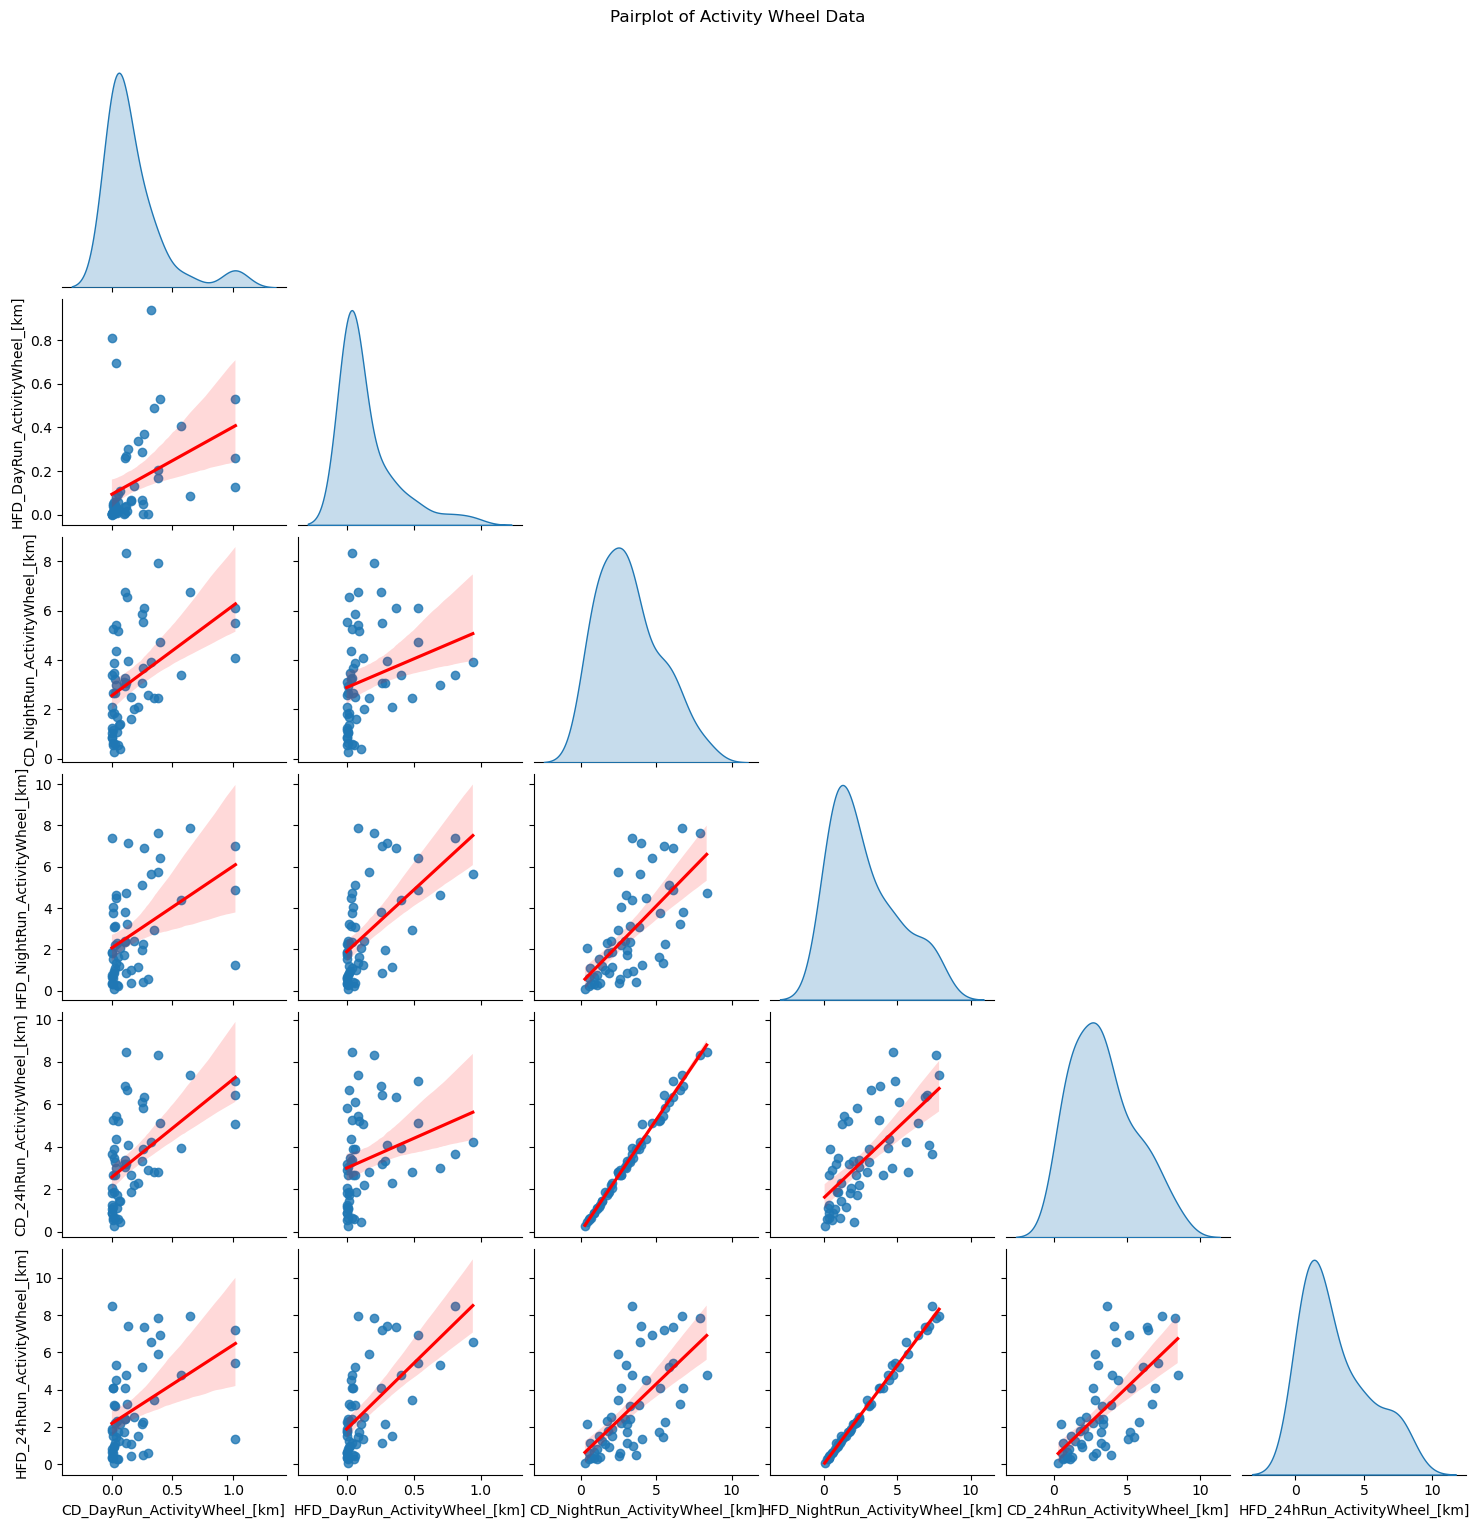

In [157]:
# YOUR CODE HERE
activityWheel_data = phenotypes['Activity Wheel']
activityWheel_data = activityWheel_data.drop(activityWheel_data.columns[0], axis=1)
activityWheel_data = activityWheel_data.drop(activityWheel_data.columns[1::3].union(activityWheel_data.columns[2::3]), axis=1)
activityWheel_data = activityWheel_data.replace('x', np.nan)
activityWheel_data = activityWheel_data.astype(float)
activityWheel_data.head()

sns.pairplot(activityWheel_data, diag_kind='kde', corner=True, kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle('Pairplot of Activity Wheel Data', y=1.02)
plt.show()


**Interpret the similarities and differences between strains, diets and the time of day. E.g: At what time of the day do mice tend to run most? Do mice that run a lot during the day run less in the night?**

Generally, mice strains that run a lot during the day run a lot in general. Mice seem to run more at daytime, since the slopes are steepest, when kms ran in a day on y are plotted against the kms ran in a day at night on x. Generally, chow diet mice seem to run less than High fat diet mice.

# Data formatting

As you can see, the raw data sheets are painful to work with: to compare the same measurements under choline deficient (CD) and high-fat diet (HFD) you have to manually look up and hard-code the column names with both versions. The CD and HFD tags are sometimes used at the beginning of the column names, sometimes at the end, differing from sheet to sheet, sometimes even within the same sheet as well. Occasionally, there are no measurements under the CD or the HFD conditions.

This is the author's fault of not making their Excel-sheets more machine readable, but such is life. We will first have to fix this ourselves.

To simplify further analysis, write a function that can transform a DataFrame from the original format:

~~~~
    @format=column CD_AAA   HFD_AAA   BBB_CD  BBB_HFD
          BXD1      15.0      16.2      76       85     ...
          BXD2      11.6      13.4      91      102
                         ...      
~~~~
into the following format:
~~~~
         strain  diet    AAA   BBB
          BXD1    CD    15.0    76  ...
          BXD1   HFD    16.2    85
          BXD2    CD    11.6    91
          BXD2   HFD    13.4   102
               ...
~~~~
We will ignore the `N` and `SD` columns (replicate counts and standard deviations) and focus on extracting the measurement means only.

One possible way of performig the transformation:
* first, rename that ugly index name (`@format=column`) into something more descriptive: `strain`. You can do this by directly naming the index with `df.index.name = strain`
* Extract all columns containing `CD_` or `_CD` into one DataFrame (`only_cd`), and all columns containing `HFD_` or `_HFD` in another DataFrame (`only_hfd`).
* Rename these DataFrames' columns using a helper function that removes `CD_`, `_CD`, `HFD_` and `_HFD` substrings. (chained replace operations should do the job).
* Insert a new column named `diet` at the beginning of both DataFrames, and fill it with the value `"CD"` for the first one, and `"HFD"` for the second.
* Find the intersection of the two DataFrame's column names (column objects have an `intersection` method) and store it in `shared_cols`. Since most of the measurements were performed under both diets, this will usually result in all, or nearly all of the columns.
* Slice the two dataframes such that only `shared_cols` columns are kept.
* Concatenate the two DataFrames, and sort them by `strain` and `diet`.
* Turn the `strain` and `diet` columns into a joint index. Since this index now has two values, it will be called a `MultiIndex`.
* Wrap all of these steps above into a function named `split_cd_hfd`, which takes a raw DataFrame as input, and returns the re-formatted DataFrame as output.

In [158]:
# Little extra help: the VO2Max table doesn't even follow their own column naming conventions, so we'll fix that first
def rename_vo2_cols(colname):
    return colname.replace('CD', 'CD_').replace('HFD', 'HFD_').replace('__', '_')

phenotypes['VO2Max'].rename(columns=rename_vo2_cols, inplace=True)

In [159]:
# YOUR CODE HERE
def split_cd_hfd(df):
    df.index.name = "strain"
    only_cd = df.loc[:, df.columns.str.contains(r"(^CD_|_CD$)")]
    only_hfd = df.loc[:, df.columns.str.contains(r"(^HFD_|_HFD$)")]
    
    only_cd.columns = only_cd.columns.str.replace(r"(^CD_|_CD$)", "", regex=True)
    only_hfd.columns = only_hfd.columns.str.replace(r"(^HFD_|_HFD$)", "", regex = True)
    
    only_cd.insert(0, "diet", "CD")
    only_hfd.insert(0, "diet", "HFD")

    shared_cols = only_cd.columns.intersection(only_hfd.columns)
    only_cd = only_cd[shared_cols]
    only_hfd = only_hfd[shared_cols]
    
    combined = pd.concat([only_cd, only_hfd])
    combined = combined.reset_index()
    combined = combined.sort_values(by=["strain", "diet"])
    combined = combined.set_index(["strain", "diet"])
    combined.columns.name = "experiment"
    return combined

## Explore the flexibility that this new representation allows you

Run `split_cd_hfd(...)` on the Activity Wheel sheet and store the result in `df`. Display the top of it with `.head()`.

In [160]:
# YOUR CODE HERE
activityWheel_data = phenotypes['Activity Wheel']
df = split_cd_hfd(activityWheel_data)
df.head()

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34664/599358809.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_cd = df.loc[:, df.columns.str.contains(r"(^CD_|_CD$)")]
/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34664/599358809.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_hfd = df.loc[:, df.columns.str.contains(r"(^HFD_|_HFD$)")]


experiment   DayRun_ActivityWheel_[km]  NightRun_ActivityWheel_[km]  \
strain diet                                                           
0      CD                     0.110775                     6.765900   
       HFD                    0.258075                     3.815375   
1      CD                     0.000833                     3.390467   
       HFD                    0.807400                     7.370660   
2      CD                     0.213000                     2.076000   

experiment   24hRun_ActivityWheel_[km]  
strain diet                             
0      CD                     6.876650  
       HFD                    4.073425  
1      CD                     3.651333  
       HFD                    8.477940  
2      CD                     2.288600

In [161]:
assert 'df' in locals()

Let's say you want to go back to the original, one-column-for-each-diet representation for some purpose. You can do it by running `df.unstack()` which turns the last level of the row MultiIndex (in our case: `diet`) into a new level of the column index. Try it out, and display the head of the resulting DataFrame.

In [162]:
# YOUR CODE HERE
df_unstacked = df.unstack()
df_unstacked.head()

experiment DayRun_ActivityWheel_[km]           NightRun_ActivityWheel_[km]  \
diet                              CD       HFD                          CD   
strain                                                                       
0                           0.110775  0.258075                    6.765900   
1                           0.000833  0.807400                    3.390467   
2                           0.213000  0.337000                    2.076000   
3                           0.064941  0.110300                    0.408927   
4                           0.117778  0.266555                    3.084563   

experiment           24hRun_ActivityWheel_[km]            
diet             HFD                        CD       HFD  
strain                                                    
0           3.815375                  6.876650  4.073425  
1           7.370660                  3.651333  8.477940  
2           1.144000                  2.288600  1.488000  
3           2.050354                  0.473750  2.158800  
4           0.863286                  3.200800  1.127000

You can also turn the row MultiIndex's `diet` level into a regular column of the DataFrame with `df.reset_index('diet')`. If you call `.reset_index()` without any arguments, it will turn every level of the index into a separate column. This is sometimes useful. Try them out.

In [163]:
# YOUR CODE HERE
df_resetIndesx = df.reset_index('diet')
df_resetIndesx.head()

experiment,diet,DayRun_ActivityWheel_[km],NightRun_ActivityWheel_[km],24hRun_ActivityWheel_[km]
strain,,,,
0,CD,0.110775,6.765900,6.876650
0,HFD,0.258075,3.815375,4.073425
1,CD,0.000833,3.390467,3.651333
1,HFD,0.807400,7.370660,8.477940
2,CD,0.213000,2.076000,2.288600


The previously used `.unstack()` is the inverse operation of `.stack()` which turns the last level of the *column* index into a new level of the *row* index. Try this one too. The resulting DataFrame now has a single column (named `0` by default) with the measurement values for every experiment type. The experiment names turned into row index labels.

Since the column index didn't have a name, the new row index doesn't have a name either. To prevent this, go back to your `split_cd_hfd()` function, and name that column index just before you return the DataFrame. You can do this with `df_to_return.column.name = 'experiment'` before you do `return df_to_return`.

Stacking may not look very useful right now, but several `seaborn` plot types expect the data in a similar, collapsed format, as you will shortly see.

In [164]:
# YOUR CODE HERE
df_stacked= df_unstacked.stack()
df_stacked.head()

experiment   DayRun_ActivityWheel_[km]  NightRun_ActivityWheel_[km]  \
strain diet                                                           
0      CD                     0.110775                     6.765900   
       HFD                    0.258075                     3.815375   
1      CD                     0.000833                     3.390467   
       HFD                    0.807400                     7.370660   
2      CD                     0.213000                     2.076000   

experiment   24hRun_ActivityWheel_[km]  
strain diet                             
0      CD                     6.876650  
       HFD                    4.073425  
1      CD                     3.651333  
       HFD                    8.477940  
2      CD                     2.288600

# Compare the two diets with respect to body weight measurements

Take the sheet `Body Wt & Composition`, fix it with `split_cd_hfd()` and slice columns 3-6 (`.iloc[:, 2:6]`) into a new DataFrame named `bodywt`.

Create two side by side histograms to get a visual overview of mice's weight distribution progression under each diet. Use the integrated `bodywt.hist(...)` method to create the histograms. It's worth taking a look at its documentation, so that you can make use of the `diet` index level.

In [165]:
# YOUR CODE HERE
bodywt = phenotypes['Body Wt & Composition']
bodywt = split_cd_hfd(bodywt)
bodywt = bodywt.iloc[:, 2:6]
bodywt.head()

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34664/599358809.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_cd = df.loc[:, df.columns.str.contains(r"(^CD_|_CD$)")]
/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34664/599358809.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_hfd = df.loc[:, df.columns.str.contains(r"(^HFD_|_HFD$)")]


experiment   BodyWeight_Wk8_[g]  BodyWeight_Wk16_[g]  BodyWeight_Wk28_[g]  \
strain diet                                                                 
0      CD                21.548               28.084                30.00   
       HFD               21.718               31.196                43.90   
1      CD                22.414               30.146                32.30   
       HFD               22.214               39.914                40.60   
2      CD                23.770               27.900                30.62   

experiment   BodyWeight_Sacrifice_[g]  
strain diet                            
0      CD                     31.3020  
       HFD                    47.2280  
1      CD                     33.5725  
       HFD                    48.3280  
2      CD                     28.3260

## Create a violin plot with the same `bodywt` data

By using seaborn's `violinplot` method, try to generate a plot with four "violins", each of them split left/right based on the diet: i.e. CD on the left side, HFD on the right side.

Seaborn expects the data to be in a very specific format for this task. Study the documentation and/or an example, and find out how you can achieve it with the previously learned `.stack()` and `.reset_index()` methods.

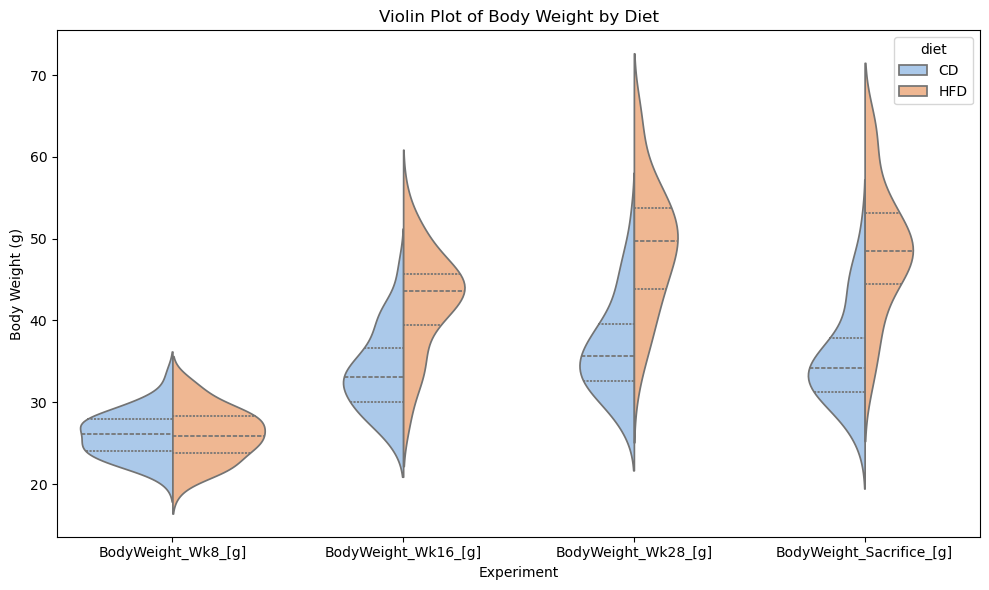

In [166]:
# YOUR CODE HERE
bodywt_long = bodywt.stack().reset_index()
bodywt_long.columns = ['strain', 'diet', 'experiment', 'value']
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=bodywt_long,
    x='experiment',
    y='value',
    hue='diet',
    split=True,
    inner='quart',
    palette='pastel'
)
plt.title('Violin Plot of Body Weight by Diet')
plt.xlabel('Experiment')
plt.ylabel('Body Weight (g)')
plt.tight_layout()
plt.show()

## Plot the linear dependence of phenotype pairs, color coded by diet

You had previously created a 6x6 `pairplot` from the raw Activity Wheel columns. Do it again on the "fixed" DataFrame, stratified by diet. Your new pairplot should be a 3x3 grid, and CD and HFD measurements should be displayed on the same plots with different coloring.

In [171]:
df.head()

experiment   DayRun_ActivityWheel_[km]  NightRun_ActivityWheel_[km]  \
strain diet                                                           
0      CD                     0.110775                     6.765900   
       HFD                    0.258075                     3.815375   
1      CD                     0.000833                     3.390467   
       HFD                    0.807400                     7.370660   
2      CD                     0.213000                     2.076000   

experiment   24hRun_ActivityWheel_[km]  
strain diet                             
0      CD                     6.876650  
       HFD                    4.073425  
1      CD                     3.651333  
       HFD                    8.477940  
2      CD                     2.288600

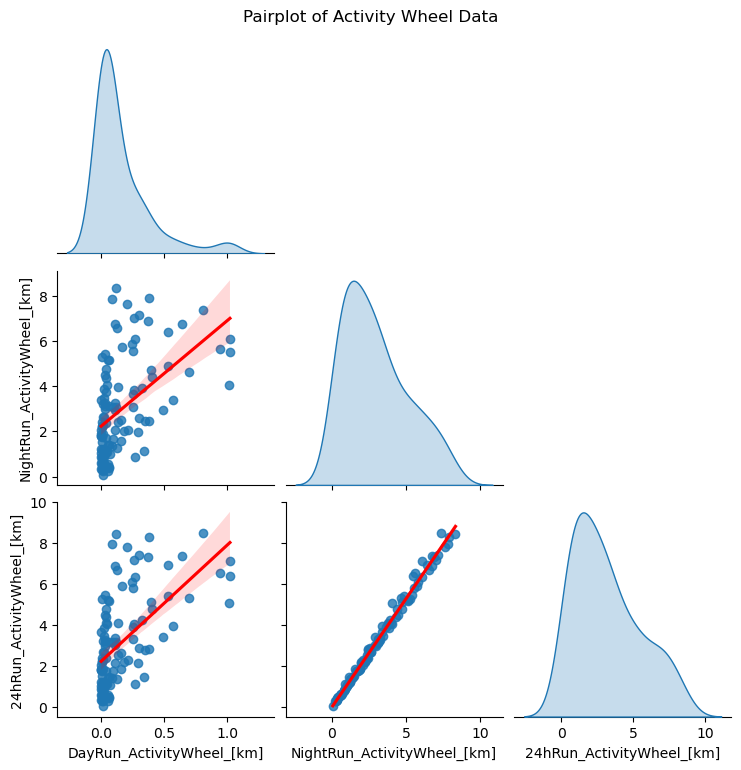

In [185]:
# YOUR CODE HERE 
sns.pairplot(df, diag_kind='kde',corner=True, kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle('Pairplot of Activity Wheel Data', y=1.02)
plt.show()

# Explore!

Compare phenotype measurements from different domains. For example, try to see if certain biochemical measurements correlate with fitness measurements or blood parameters. You are free to choose the phenotypes that you compare, but they should be heterogenous.

Pairplots are a great way of visualizing correlations between multiple parameters, but you can play with other kinds of techniques and plots as well. You are given complete freedom here -- try to find something interesting!

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()